In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

csv_files = list(Path("output").rglob("*.csv"))
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

df = df.dropna(subset=["classifier"])
df = df.drop_duplicates(subset=["dataset", "classifier", "num_features"], keep="last")
df = df.sort_values(["dataset", "classifier"]).reset_index(drop=True)

df["total_time"] = (
    df["train_time"] + df["test_time"]
    + df["generate_kernel_time"]
    + df["apply_kernel_on_train_time"]
    + df["apply_kernel_on_test_time"]
)

DATASETS = ["InsectWingbeatSound", "StarLightCurves", "ElectricDevices", "Crop"]
CLASSIFIERS = ["MultiRocket_49728", "mlp_MultiRocket_49728", "rf_MultiRocket_49728",
               "skew_MultiRocket_62160", "var_MultiRocket_62160"]
LABELS = {
    "MultiRocket_49728":      "Baseline",
    "mlp_MultiRocket_49728":  "MLP",
    "rf_MultiRocket_49728":   "RF",
    "skew_MultiRocket_62160": "Skew",
    "var_MultiRocket_62160":  "Var",
}

df = df[df["dataset"].isin(DATASETS)]
df = df[df["classifier"].isin(CLASSIFIERS)]
df["label"] = df["classifier"].map(LABELS)

display(df[["dataset", "label", "num_features", "test_acc", "total_time"]])

,dataset,label,num_features,test_acc,total_time
2,Crop,RF,49728.0,0.758571,44.562995
5,ElectricDevices,RF,49728.0,0.726624,75.208709
7,InsectWingbeatSound,Baseline,49728.0,0.637374,2.833681
8,InsectWingbeatSound,MLP,49728.0,0.623737,3.626368
9,InsectWingbeatSound,RF,49728.0,0.666667,2.560905
10,InsectWingbeatSound,Skew,62160.0,0.618687,3.416651
11,InsectWingbeatSound,Var,62160.0,0.626768,3.797745
13,StarLightCurves,Baseline,49728.0,0.979966,13.415214
14,StarLightCurves,MLP,49728.0,0.977659,15.206165
15,StarLightCurves,RF,49728.0,0.980330,23.273397


/var/folders/9c/1v0660y55c167t80_dblpyl00000gn/T/ipykernel_11535/2990910498.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=data, x="label", y="test_acc",
/var/folders/9c/1v0660y55c167t80_dblpyl00000gn/T/ipykernel_11535/2990910498.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=data, x="label", y="test_acc",
/var/folders/9c/1v0660y55c167t80_dblpyl00000gn/T/ipykernel_11535/2990910498.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=data, x="label", y="test_acc",
/var/folders/9c/1v0660y55c167t8

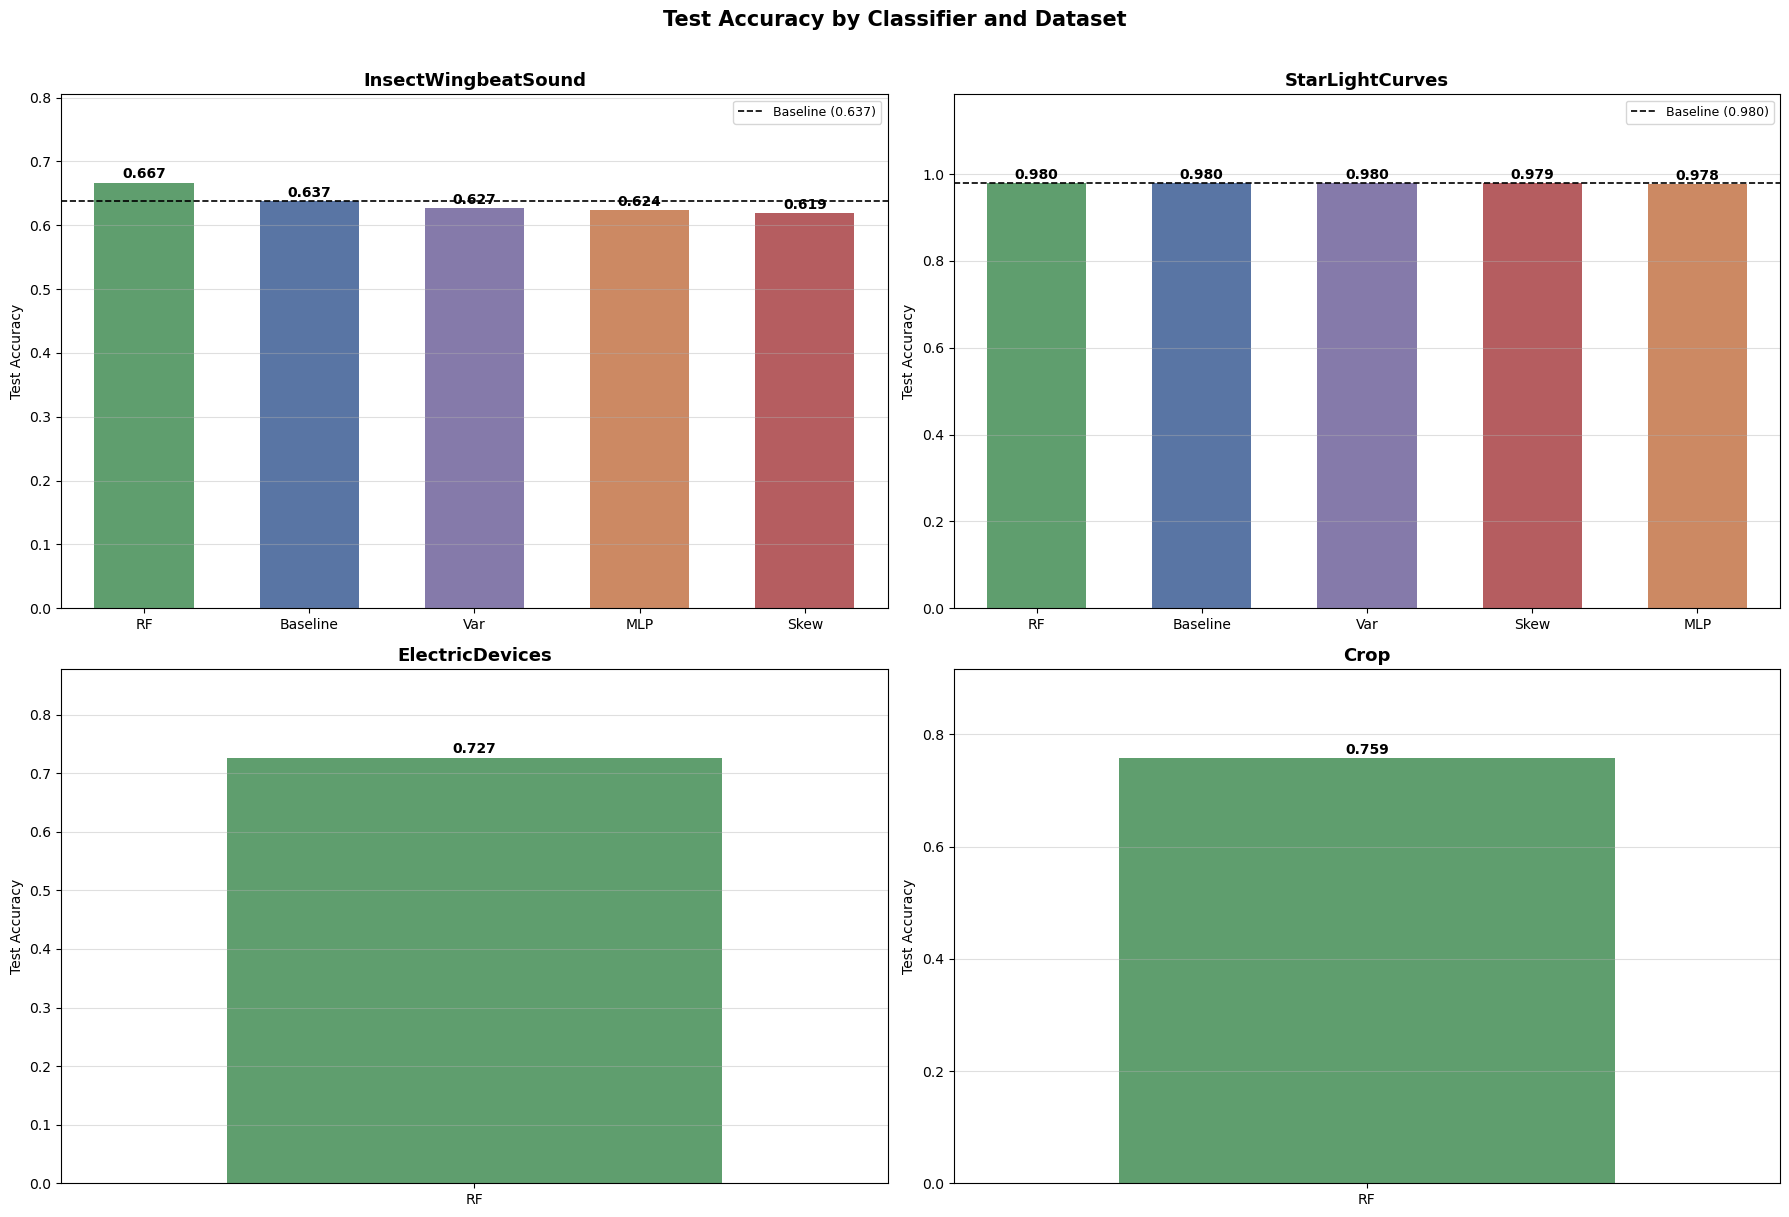

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

palette = {"Baseline": "#4C72B0", "MLP": "#DD8452", "RF": "#55A868",
           "Skew": "#C44E52", "Var": "#8172B2"}

for i, dataset in enumerate(DATASETS):
    ax = axes[i]
    data = df[df["dataset"] == dataset].sort_values("test_acc", ascending=False)

    bars = sns.barplot(data=data, x="label", y="test_acc",
                       palette=palette, ax=ax, width=0.6)

    baseline_acc = data[data["label"] == "Baseline"]["test_acc"].values
    if len(baseline_acc):
        ax.axhline(y=baseline_acc[0], color="black", linestyle="--",
                   linewidth=1.2, label=f"Baseline ({baseline_acc[0]:.3f})")
        ax.legend(fontsize=9)

    ymin, ymax = ax.get_ylim()
    ax.set_ylim(ymin, ymax * 1.15)
    for p in ax.patches:
        h = p.get_height()
        if h > 0:
            ax.text(p.get_x() + p.get_width()/2, h + 0.002,
                    f"{h:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

    ax.set_title(f"{dataset}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Test Accuracy")
    ax.grid(axis="y", alpha=0.4)

plt.suptitle("Test Accuracy by Classifier and Dataset", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("output/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

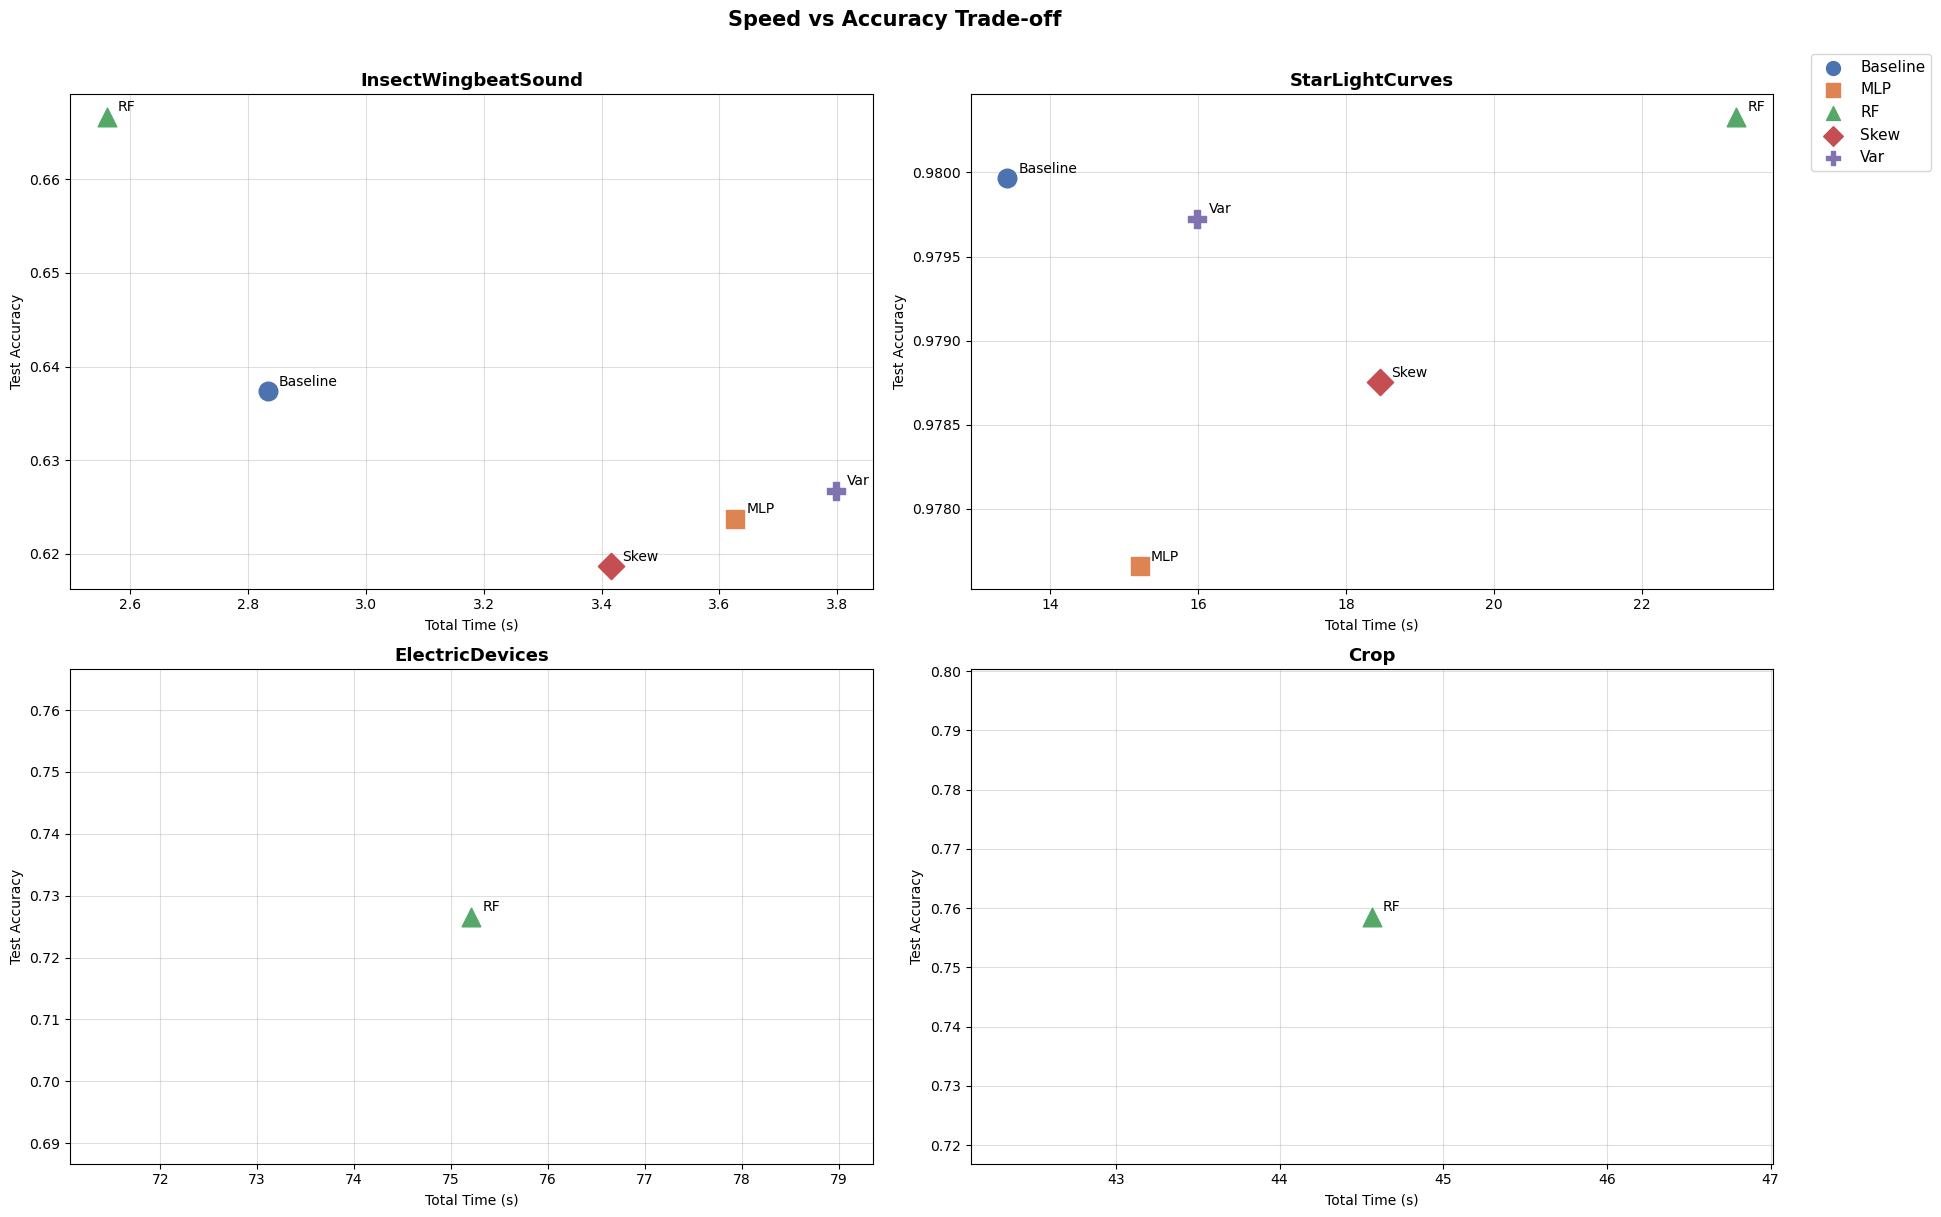

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

markers = {"Baseline": "o", "MLP": "s", "RF": "^", "Skew": "D", "Var": "P"}

for i, dataset in enumerate(DATASETS):
    ax = axes[i]
    data = df[df["dataset"] == dataset]

    for _, row in data.iterrows():
        ax.scatter(row["total_time"], row["test_acc"],
                   color=palette[row["label"]],
                   marker=markers[row["label"]],
                   s=180, zorder=5, label=row["label"])
        ax.annotate(row["label"],
                    (row["total_time"], row["test_acc"]),
                    textcoords="offset points", xytext=(8, 4), fontsize=10)

    ax.set_title(f"{dataset}", fontsize=13, fontweight="bold")
    ax.set_xlabel("Total Time (s)")
    ax.set_ylabel("Test Accuracy")
    ax.grid(alpha=0.4)

handles = [plt.scatter([], [], color=palette[l], marker=markers[l], s=100, label=l)
           for l in LABELS.values()]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.08, 0.98), fontsize=11)
plt.suptitle("Speed vs Accuracy Trade-off", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("output/speed_vs_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

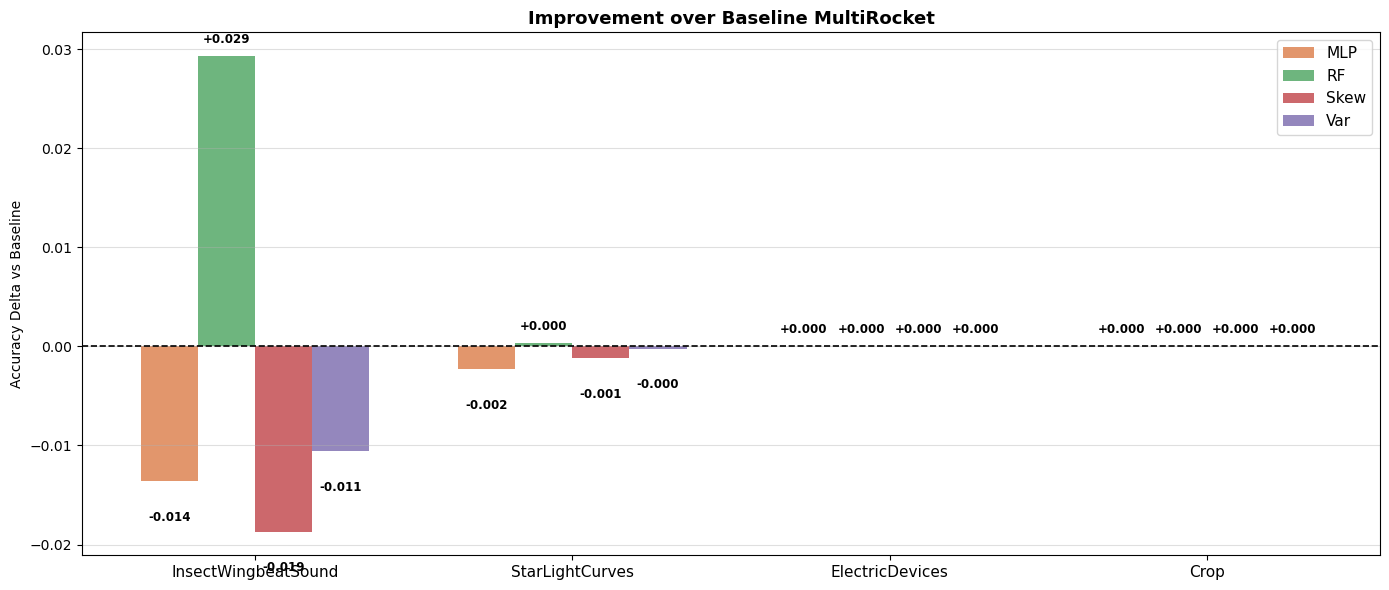

In [4]:
baseline = df[df["label"] == "Baseline"][["dataset", "test_acc"]].rename(
    columns={"test_acc": "baseline_acc"})

df_delta = df[df["label"] != "Baseline"].merge(baseline, on="dataset")
df_delta["delta"] = df_delta["test_acc"] - df_delta["baseline_acc"]

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(DATASETS))
improvers = [l for l in LABELS.values() if l != "Baseline"]
width = 0.18

for j, label in enumerate(improvers):
    vals = []
    for ds in DATASETS:
        row = df_delta[(df_delta["dataset"] == ds) & (df_delta["label"] == label)]
        vals.append(row["delta"].values[0] if len(row) else 0)
    offset = (j - len(improvers)/2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=label,
                  color=palette[label], alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (0.001 if val >= 0 else -0.003),
                f"{val:+.3f}", ha="center",
                va="bottom" if val >= 0 else "top",
                fontsize=8.5, fontweight="bold")

ax.axhline(0, color="black", linewidth=1.2, linestyle="--")
ax.set_xticks(x)
ax.set_xticklabels(DATASETS, fontsize=11)
ax.set_ylabel("Accuracy Delta vs Baseline")
ax.set_title("Improvement over Baseline MultiRocket", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("output/delta_over_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
pivot_acc = df.pivot_table(index="label", columns="dataset", values="test_acc").round(4)

rank = pivot_acc.rank(ascending=False, axis=0, na_option="bottom").round(0).astype("Int64")
rank.index = [f"{l} (rank)" for l in rank.index]

print("=== Test Accuracy ===")
display(pivot_acc)
print()
print("=== Rank (1 = best) ===")
display(rank)

pivot_acc["Mean Acc"] = pivot_acc.mean(axis=1).round(4)
mean_rank = pivot_acc.rank(ascending=False, axis=0, na_option="bottom").mean(axis=1).round(2)
pivot_acc["Mean Rank"] = mean_rank

print()
print("=== Overall ===")
display(pivot_acc[["Mean Acc", "Mean Rank"]].sort_values("Mean Acc", ascending=False))

=== Test Accuracy ===


dataset,Crop,ElectricDevices,InsectWingbeatSound,StarLightCurves
label,,,,
Baseline,NaN,NaN,0.6374,0.9800
MLP,NaN,NaN,0.6237,0.9777
RF,0.7586,0.7266,0.6667,0.9803
Skew,NaN,NaN,0.6187,0.9788
Var,NaN,NaN,0.6268,0.9797



=== Rank (1 = best) ===


dataset,Crop,ElectricDevices,InsectWingbeatSound,StarLightCurves
Baseline (rank),4,4,2,2
MLP (rank),4,4,4,5
RF (rank),1,1,1,1
Skew (rank),4,4,5,4
Var (rank),4,4,3,3



=== Overall ===


dataset,Mean Acc,Mean Rank
label,,
Baseline,0.8087,2.4
Var,0.8032,3.0
MLP,0.8007,3.8
Skew,0.7988,4.0
RF,0.7830,1.8


dataset,Crop,ElectricDevices,InsectWingbeatSound,StarLightCurves,Mean Time (s)
label,,,,,
Baseline,NaN,NaN,2.83,13.42,8.12
MLP,NaN,NaN,3.63,15.21,9.42
Var,NaN,NaN,3.80,15.99,9.90
Skew,NaN,NaN,3.42,18.46,10.94
RF,44.56,75.21,2.56,23.27,36.40


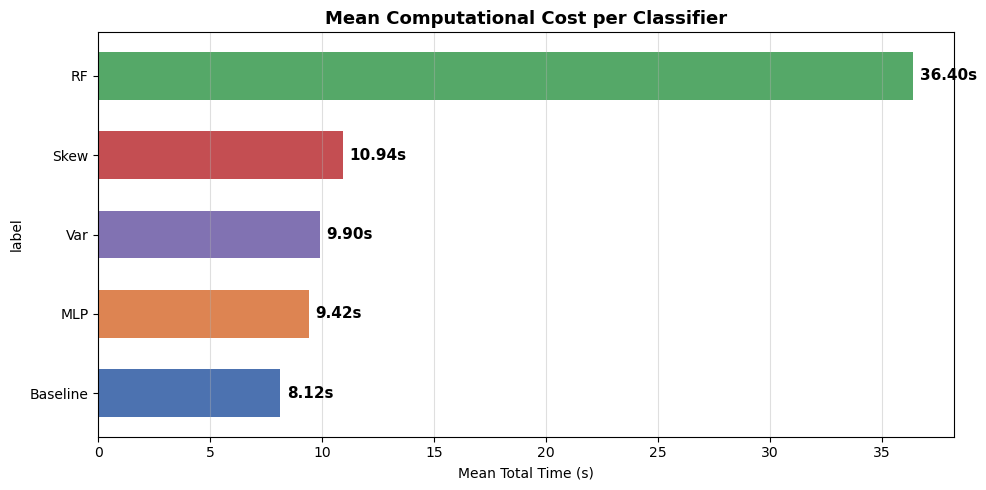

In [7]:
pivot_time = df.pivot_table(index="label", columns="dataset", values="total_time").round(2)
pivot_time["Mean Time (s)"] = pivot_time.mean(axis=1).round(2)
pivot_time = pivot_time.sort_values("Mean Time (s)")

display(pivot_time)

fig, ax = plt.subplots(figsize=(10, 5))
pivot_time["Mean Time (s)"].plot(kind="barh", ax=ax,
    color=[palette[l] for l in pivot_time.index], width=0.6)

for i, (val, label) in enumerate(zip(pivot_time["Mean Time (s)"], pivot_time.index)):
    ax.text(val + 0.3, i, f"{val:.2f}s", va="center", fontsize=11, fontweight="bold")

ax.set_xlabel("Mean Total Time (s)")
ax.set_title("Mean Computational Cost per Classifier", fontsize=13, fontweight="bold")
ax.grid(axis="x", alpha=0.4)
plt.tight_layout()
plt.savefig("output/time_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("Best classifier per dataset (by test accuracy):\n")
for ds in DATASETS:
    data = df[df["dataset"] == ds].sort_values("test_acc", ascending=False)
    best = data.iloc[0]
    baseline_row = data[data["label"] == "Baseline"]
    baseline_acc = baseline_row["test_acc"].values[0] if len(baseline_row) else None
    delta = f" (+{best['test_acc'] - baseline_acc:.4f} vs baseline)" if baseline_acc else ""
    print(f"  {ds:<22} → {best['label']:<10} ({best['test_acc']:.4f}{delta})")

Best classifier per dataset (by test accuracy):

  InsectWingbeatSound    → RF         (0.6667 (+0.0293 vs baseline))
  StarLightCurves        → RF         (0.9803 (+0.0004 vs baseline))
  ElectricDevices        → RF         (0.7266)
  Crop                   → RF         (0.7586)
